# Examen Final - Interpretabilidad y Causalidad en Machine Learning

**Dataset**: LaLonde (NSW tratados vs PSID controles)  
**Alumno**: Juan Carlos Ramírez  
**Fecha**: Agosto 2026

---

## Preparacion general

### Imports y configuracion

In [22]:
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("default")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.random.seed(42)

### Carga de datos y validacion

La fuente oficial del examen es el CSV publicado en GitHub. Para que el notebook sea rapido durante el desarrollo, primero intenta cargar el respaldo local `../data/input/Datos Lalonde.csv`; si ese archivo no existe, descarga el CSV desde la URL del examen usando `?raw=1`.


In [23]:
BASE_DIR = Path("..")
DATA_URL = "https://github.com/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/lalonde_data.csv"
DATA_DOWNLOAD_URL = f"{DATA_URL}?raw=1"
LOCAL_DATA_PATH = BASE_DIR / "data" / "input" / "Datos Lalonde.csv"
OUTPUT_DIR = BASE_DIR / "data" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if LOCAL_DATA_PATH.exists():
    df = pd.read_csv(LOCAL_DATA_PATH)
    data_source = f"{LOCAL_DATA_PATH} (respaldo local; URL oficial: {DATA_URL})"
else:
    with urlopen(DATA_DOWNLOAD_URL, timeout=15) as response:
        df = pd.read_csv(BytesIO(response.read()))
    data_source = DATA_URL

print(f"Fuente de datos: {data_source}")
print(f"Dimensiones: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
print(f"Nulos: {df.isna().sum().sum()}")
df.head()


Fuente de datos: ../data/input/Datos Lalonde.csv (respaldo local; URL oficial: https://github.com/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/lalonde_data.csv)
Dimensiones: (614, 11)
Columnas: ['ID', 'treat', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're74', 're75', 're78']
Nulos: 0


,ID,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,NSW1,1,37,11,1,0,1,1,0.0000,0.0000,"9,930.0460"
1,NSW2,1,22,9,0,1,0,1,0.0000,0.0000,"3,595.8940"
2,NSW3,1,30,12,1,0,0,0,0.0000,0.0000,"24,909.4500"
3,NSW4,1,27,11,1,0,0,1,0.0000,0.0000,"7,506.1460"
4,NSW5,1,33,8,1,0,0,1,0.0000,0.0000,289.7899


In [24]:
# Confirmar la estructura NSW vs PSID
df["source"] = df["ID"].str.extract(r"^([A-Za-z]+)")
pd.crosstab(df["source"], df["treat"], margins=True)

treat,0,1,All
source,,,
NSW,0,185,185
PSID,429,0,429
All,429,185,614


### Nota metodologica sobre el dataset

Aunque LaLonde suele asociarse con el experimento NSW, el archivo usado aqui no corresponde al ensayo experimental puro. Los individuos tratados tienen identificadores `NSW`, mientras que los controles tienen identificadores `PSID`.

Por lo tanto, este analisis se trata como un **estudio observacional** con tratados NSW y controles PSID. El efecto causal no se identifica por aleatorizacion simple, sino bajo el supuesto de ignorabilidad condicional dado el conjunto de covariables pretratamiento:

`X = {age, educ, black, hispan, married, nodegree, re74, re75}`

No se utiliza `ID` como covariable porque codifica el origen de la muestra y separa perfectamente tratamiento/control. Tampoco se ajusta por `re78`, ya que es la variable de resultado posterior al tratamiento.

El puntaje de propension permite reponderar la poblacion para hacer la comparacion entre tratados y controles mas parecida a una asignacion aleatoria o A/B testing.

### Definicion de variables

In [25]:
D = "treat"
Y = "re78"
X_cols = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75"]

# Medias por grupo
df.groupby(D)[X_cols + [Y]].mean().T

treat,0,1
age,28.0303,25.8162
educ,10.2354,10.3459
black,0.2028,0.8432
hispan,0.1422,0.0595
married,0.5128,0.1892
nodegree,0.5967,0.7081
re74,"5,619.2365","2,095.5737"
re75,"2,466.4844","1,532.0553"
re78,"6,984.1697","6,349.1435"


Las medias por grupo sugieren diferencias importantes antes del tratamiento. En particular, los ingresos previos (`re74`, `re75`) y la composicion racial difieren de forma clara entre tratados y controles. Esto anticipa problemas potenciales de solapamiento/positividad.

---

## Pregunta 1: IPW, modelos de resultado y DAG

### 1.1 Puntaje de propension

Estimamos el puntaje de propension:

$$e(X) = P(D = 1 \mid X)$$

usando una regresion logistica con covariables pretratamiento. El objetivo no es predecir por si mismo, sino evaluar solapamiento y construir pesos IPW.

In [26]:
X = df[X_cols]
d = df[D].to_numpy()
y = df[Y].to_numpy()

propensity_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=10_000, solver="lbfgs")),
])

propensity_model.fit(X, d)
df["propensity"] = propensity_model.predict_proba(X)[:, 1]

auc = roc_auc_score(d, df["propensity"])
print(f"AUC del modelo de propension: {auc:.3f}")
df.groupby(D)["propensity"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

AUC del modelo de propension: 0.874


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
treat,,,,,,,,,,,,
0,429.0000,0.1834,0.2274,0.0101,0.0120,0.0180,0.0411,0.0798,0.1943,0.7016,0.7460,0.7824
1,185.0000,0.5748,0.2176,0.0269,0.0455,0.0994,0.5267,0.6517,0.7222,0.7721,0.8080,0.8442


### 1.2 Distribucion del puntaje y solapamiento

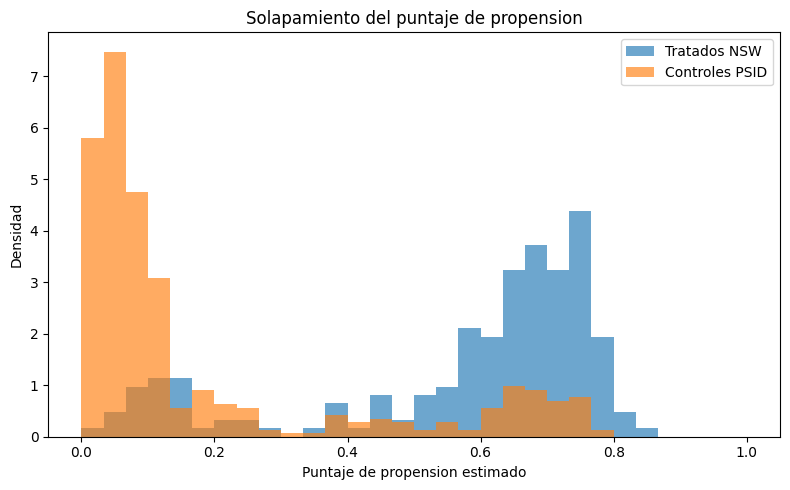

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(0, 1, 31)
ax.hist(df.loc[df[D] == 1, "propensity"], bins=bins, alpha=0.65, density=True, label="Tratados NSW")
ax.hist(df.loc[df[D] == 0, "propensity"], bins=bins, alpha=0.65, density=True, label="Controles PSID")
ax.set_xlabel("Puntaje de propension estimado")
ax.set_ylabel("Densidad")
ax.set_title("Solapamiento del puntaje de propension")
ax.legend()
fig.tight_layout()

La distribucion del puntaje de propension debe interpretarse como diagnostico de **positividad**. Si hay muchas observaciones cerca de 0 o 1, los pesos IPW pueden volverse extremos. En este caso el modelo distingue bastante bien tratados de controles (AUC ~ 0.87), lo que es consistente con el origen NSW vs PSID y sugiere solapamiento imperfecto.

### 1.3 Pesos IPW para ATE

Para ATE se usan pesos:

$$w_i = \frac{D_i}{e(X_i)} + \frac{1 - D_i}{1 - e(X_i)}$$

Tambien calculamos una version estabilizada/normalizada por grupo para revisar sensibilidad a pesos extremos.

In [28]:
eps = 0.01
df["propensity_clipped"] = df["propensity"].clip(eps, 1 - eps)

e = df["propensity_clipped"].to_numpy()
df["w_ate"] = d / e + (1 - d) / (1 - e)
df["w_att"] = np.where(d == 1, 1.0, e / (1 - e))

print("Diagnostico de pesos ATE:")
df["w_ate"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

Diagnostico de pesos ATE:


count   614.0000
mean      1.8850
std       2.4680
min       1.0102
50%       1.1762
90%       3.1346
95%       4.0079
99%      11.9937
max      37.2368
Name: w_ate, dtype: float64

In [29]:
# Observaciones con pesos mas extremos
df.sort_values("w_ate", ascending=False)[
    ["ID", D, "age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75", Y, "propensity", "w_ate"]
].head(10)

,ID,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,propensity,w_ate
123,NSW124,1,27,13,0,0,1,0,"9,381.5660",853.7225,0.0000,0.0269,37.2368
9,NSW10,1,33,12,0,0,1,0,0.0000,0.0000,"12,418.0700",0.0453,22.0676
136,NSW137,1,23,8,0,0,1,1,0.0000,"1,713.1500","4,232.3090",0.0455,21.9767
115,NSW116,1,21,12,0,0,0,0,"3,670.8720",334.0494,"12,558.0200",0.0665,15.0437
67,NSW68,1,23,7,0,0,0,1,0.0000,0.0000,0.0000,0.0785,12.7314
178,NSW179,1,22,12,0,0,0,0,"6,759.9940","8,455.5040","12,590.7100",0.0805,12.4246
88,NSW89,1,21,12,0,0,0,0,0.0000,0.0000,"8,048.6030",0.0828,12.0758
95,NSW96,1,25,12,0,0,0,0,0.0000,0.0000,"5,587.5030",0.0874,11.4439
43,NSW44,1,18,8,0,1,1,1,0.0000,0.0000,"2,787.9600",0.0926,10.8027
41,NSW42,1,19,9,0,0,0,1,0.0000,0.0000,"13,188.8300",0.0983,10.1705


Los pesos mas grandes corresponden a unidades observadas en un grupo para el que el modelo les asignaba baja probabilidad. IPW puede corregir desbalance observado, pero tambien puede volverse sensible cuando la positividad practica es debil.

### 1.4 Balance de covariables (SMD)

Usamos diferencias de medias estandarizadas (SMD) antes y despues de ponderar por IPW. Valores absolutos mas cercanos a cero indican mejor balance.

In [30]:
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)


def smd(x, treat, weights=None):
    x = np.asarray(x, dtype=float)
    treat = np.asarray(treat)

    if weights is None:
        x1, x0 = x[treat == 1], x[treat == 0]
        m1, m0 = x1.mean(), x0.mean()
        v1, v0 = x1.var(ddof=1), x0.var(ddof=1)
    else:
        w = np.asarray(weights, dtype=float)
        x1, w1 = x[treat == 1], w[treat == 1]
        x0, w0 = x[treat == 0], w[treat == 0]
        m1 = weighted_mean(x1, w1)
        m0 = weighted_mean(x0, w0)
        v1 = weighted_var(x1, w1)
        v0 = weighted_var(x0, w0)

    denom = np.sqrt((v1 + v0) / 2)
    if denom < 1e-10:
        return 0.0
    return (m1 - m0) / denom


balance_rows = []
for col in X_cols:
    raw = smd(df[col].values, d)
    ipw = smd(df[col].values, d, weights=df["w_ate"].values)
    balance_rows.append({"covariate": col, "smd_unweighted": raw, "smd_ipw_ate": ipw,
                         "abs_smd_unweighted": abs(raw), "abs_smd_ipw_ate": abs(ipw)})

balance = pd.DataFrame(balance_rows)
balance

,covariate,smd_unweighted,smd_ipw_ate,abs_smd_unweighted,abs_smd_ipw_ate
0,age,-0.2419,-0.1714,0.2419,0.1714
1,educ,0.0448,0.1306,0.0448,0.1306
2,black,1.6677,0.1273,1.6677,0.1273
3,hispan,-0.2769,0.0234,0.2769,0.0234
4,married,-0.7195,-0.2077,0.7195,0.2077
5,nodegree,0.2350,-0.0996,0.2350,0.0996
6,re74,-0.5958,-0.2748,0.5958,0.2748
7,re75,-0.2870,-0.1599,0.2870,0.1599


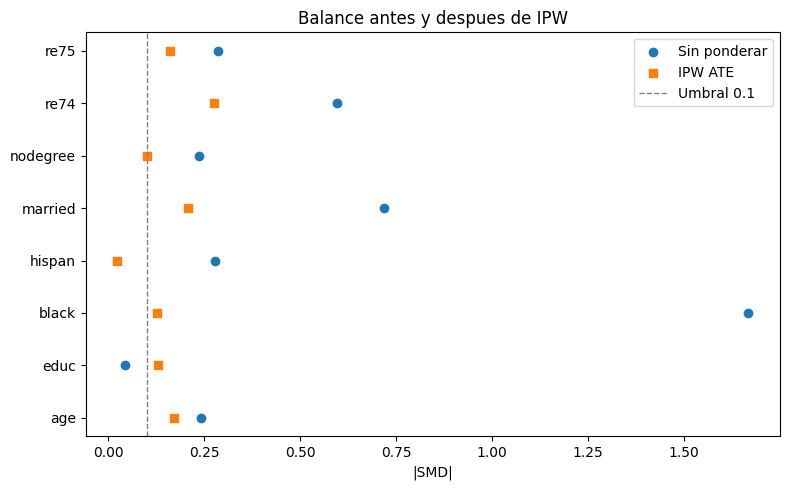

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
ypos = np.arange(len(balance))

ax.scatter(balance["abs_smd_unweighted"], ypos, label="Sin ponderar", marker="o")
ax.scatter(balance["abs_smd_ipw_ate"], ypos, label="IPW ATE", marker="s")
ax.axvline(0.1, color="gray", linestyle="--", linewidth=1, label="Umbral 0.1")
ax.set_yticks(ypos)
ax.set_yticklabels(balance["covariate"])
ax.set_xlabel("|SMD|")
ax.set_title("Balance antes y despues de IPW")
ax.legend()
fig.tight_layout()

IPW mejora considerablemente el balance en variables como `black`, `hispan` y `nodegree`, aunque no deja todas las covariables perfectamente balanceadas. Esto es esperado dado el solapamiento imperfecto entre NSW y PSID.

### 1.5 Estimadores IPW

In [32]:
ate_naive = df.loc[d == 1, Y].mean() - df.loc[d == 0, Y].mean()

ate_ipw = np.mean(d * y / e) - np.mean((1 - d) * y / (1 - e))

ate_ipw_normalized = (
    np.sum(d * y / e) / np.sum(d / e)
    - np.sum((1 - d) * y / (1 - e)) / np.sum((1 - d) / (1 - e))
)

att_ipw = (
    df.loc[d == 1, Y].mean()
    - np.sum((1 - d) * e * y / (1 - e)) / np.sum((1 - d) * e / (1 - e))
)

ipw_results = pd.DataFrame({
    "estimador": ["Diferencia cruda", "ATE IPW", "ATE IPW normalizado", "ATT IPW"],
    "estimacion": [ate_naive, ate_ipw, ate_ipw_normalized, att_ipw],
})
ipw_results

,estimador,estimacion
0,Diferencia cruda,-635.0262
1,ATE IPW,-536.1715
2,ATE IPW normalizado,232.4212
3,ATT IPW,"1,214.7822"


Si el ATE IPW no normalizado y el normalizado difieren de forma importante, esto no debe leerse como una contradiccion simple. Es evidencia de sensibilidad a pesos extremos y a falta de solapamiento perfecto.

### 1.6 Modelo de resultados

Estimamos un modelo de resultados de la forma:

$$E[Y \mid D, X]$$

y generamos dos predicciones potenciales para cada individuo:

- $\hat{\mu}_1(X) = \hat{E}[Y \mid D = 1, X]$
- $\hat{\mu}_0(X) = \hat{E}[Y \mid D = 0, X]$

Luego:

$$\widehat{ATE} = \frac{1}{n} \sum_i [\hat{\mu}_1(X_i) - \hat{\mu}_0(X_i)]$$

$$\widehat{ATT} = \frac{1}{n_1} \sum_{i: D_i=1} [\hat{\mu}_1(X_i) - \hat{\mu}_0(X_i)]$$

In [33]:
result_features = [D] + X_cols
X_result = df[result_features].copy()

outcome_model = LinearRegression()
outcome_model.fit(X_result, y)

X_treated = X_result.copy()
X_control = X_result.copy()
X_treated[D] = 1
X_control[D] = 0

mu1 = outcome_model.predict(X_treated)
mu0 = outcome_model.predict(X_control)

ate_outcome = np.mean(mu1 - mu0)
att_outcome = np.mean((mu1 - mu0)[d == 1])

# Version ponderada por IPW
weighted_outcome_model = LinearRegression()
weighted_outcome_model.fit(X_result, y, sample_weight=df["w_ate"])

mu1_w = weighted_outcome_model.predict(X_treated)
mu0_w = weighted_outcome_model.predict(X_control)

ate_outcome_ipw = np.mean(mu1_w - mu0_w)
att_outcome_ipw = np.mean((mu1_w - mu0_w)[d == 1])

outcome_results = pd.DataFrame({
    "estimador": ["ATE Modelo Resultados", "ATT Modelo Resultados",
                  "ATE Modelo Resultados + IPW", "ATT Modelo Resultados + IPW"],
    "estimacion": [ate_outcome, att_outcome, ate_outcome_ipw, att_outcome_ipw],
})
outcome_results

,estimador,estimacion
0,ATE Modelo Resultados,"1,548.2438"
1,ATT Modelo Resultados,"1,548.2438"
2,ATE Modelo Resultados + IPW,732.6367
3,ATT Modelo Resultados + IPW,732.6367


### 1.7 Comparacion de todos los estimadores

In [34]:
all_results = pd.concat([ipw_results, outcome_results], ignore_index=True)
all_results.round({"estimacion": 2})


,estimador,estimacion
0,Diferencia cruda,-635.0300
1,ATE IPW,-536.1700
2,ATE IPW normalizado,232.4200
3,ATT IPW,"1,214.7800"
4,ATE Modelo Resultados,"1,548.2400"
5,ATT Modelo Resultados,"1,548.2400"
6,ATE Modelo Resultados + IPW,732.6400
7,ATT Modelo Resultados + IPW,732.6400


**Interpretacion**: La diferencia cruda de medias mezcla el efecto del programa con diferencias previas entre NSW y PSID. IPW intenta corregir este desbalance reponderando controles y tratados, pero puede ser inestable si los puntajes de propension son extremos. El modelo de resultados suele ser mas estable, aunque depende de su especificacion y puede extrapolar en regiones donde no existen buenos controles comparables.

En este contexto, el ATT es especialmente relevante porque evalua el efecto del programa NSW sobre quienes efectivamente lo recibieron. Las diferencias entre estimadores reflejan la sensibilidad al metodo y a los supuestos de identificacion, no necesariamente una contradiccion.

### 1.8 DAG causal propuesto

El DAG propuesto representa que las covariables pretratamiento afectan tanto la probabilidad de recibir tratamiento como los ingresos posteriores.

```mermaid
flowchart LR
  A["age"] --> D["treat"]
  E["educ"] --> D
  B["black"] --> D
  H["hispan"] --> D
  M["married"] --> D
  N["nodegree"] --> D
  R74["re74"] --> D
  R75["re75"] --> D

  A --> Y["re78"]
  E --> Y
  B --> Y
  H --> Y
  M --> Y
  N --> Y
  R74 --> Y
  R75 --> Y

  E --> N
  R74 --> R75

  D --> Y
```

El arco `educ -> nodegree` refleja que `nodegree` esta derivada/relacionada con educacion. El arco `re74 -> re75` captura que el ingreso previo mas antiguo afecta el ingreso previo mas reciente. `ID` no aparece en el DAG causal sustantivo.

### 1.9 Conjunto de ajuste/backdoor

El conjunto de ajuste propuesto es:

$$\mathcal{S} = \{\text{age, educ, black, hispan, married, nodegree, re74, re75}\}$$

Estas variables son pretratamiento y afectan plausiblemente tanto la participacion en el programa como el ingreso posterior. Al condicionar en ellas, se bloquean todos los caminos backdoor entre `treat` y `re78`.

La identificacion causal depende de dos supuestos fuertes:

1. **Ignorabilidad condicional**: no quedan confusores no observados despues de ajustar por $X$.
2. **Positividad**: $0 < P(D = 1 \mid X) < 1$ para todo valor de $X$ en el soporte.

El solapamiento imperfecto sugiere que la positividad practica es debil, lo que explica la variabilidad de las estimaciones.

---

## Pregunta 2: ¿El teorema de Frisch-Waugh-Lovell prohibe el fenomeno paradojico de Simpson?

No. El teorema de Frisch-Waugh-Lovell (FWL) no prohibe la paradoja de Simpson. Mas bien, FWL ayuda a entender algebraicamente por que puede aparecer una inversion entre una asociacion agregada y una asociacion ajustada por covariables.

Para mantener continuidad con la pregunta 1, usamos el mismo dataset de LaLonde. En este archivo, la comparacion cruda entre tratados NSW y controles PSID sugiere un efecto negativo del tratamiento sobre `re78`; sin embargo, al ajustar por las covariables pretratamiento, el coeficiente de `treat` se vuelve positivo. Esa inversion ilustra un fenomeno tipo Simpson: la asociacion agregada esta contaminada por diferencias de composicion entre tratados y controles.


### 2.1 Regresion agregada vs regresion ajustada

En una regresion simple:

$$Y = \alpha + \beta_{simple}D + u,$$

el coeficiente $\beta_{simple}$ mide la asociacion agregada entre tratamiento $D$ y resultado $Y$. En este caso:

$$D = \text{treat}, \qquad Y = \text{re78}.$$

Pero los tratados NSW y los controles PSID no son comparables antes del tratamiento. Por eso consideramos tambien la regresion ajustada:

$$Y = \alpha + \beta_{ajustado}D + \gamma'X + \varepsilon,$$

donde:

$$X = \{\text{age, educ, black, hispan, married, nodegree, re74, re75}\}.$$

El coeficiente $\beta_{ajustado}$ mide la relacion entre `treat` y `re78` despues de remover linealmente la parte explicada por las covariables pretratamiento.


### 2.2 Frisch-Waugh-Lovell

El teorema de Frisch-Waugh-Lovell dice que el coeficiente $\beta_{ajustado}$ de la regresion completa puede obtenerse en tres pasos:

1. Residualizar el resultado respecto de $X$:  
   $$\tilde{Y} = Y - \widehat{E}[Y \mid X]$$

2. Residualizar el tratamiento respecto de $X$:  
   $$\tilde{D} = D - \widehat{E}[D \mid X]$$

3. Regresar los residuales:  
   $$\tilde{Y} = \beta_{FWL}\tilde{D} + \eta$$

Entonces:

$$\beta_{FWL} = \beta_{ajustado}.$$

Esto no impone que $\beta_{simple}$ y $\beta_{ajustado}$ tengan el mismo signo. Por lo tanto, FWL no elimina ni prohibe Simpson; permite ver como cambia el coeficiente cuando se controla por las covariables.


### 2.3 Sesgo por variable omitida

En el caso lineal, la diferencia entre el coeficiente simple y el ajustado puede pensarse como sesgo por variable omitida:

$$\beta_{simple} = \beta_{ajustado} + \text{termino de confusion}.$$

Si las covariables $X$ estan asociadas con el tratamiento y tambien con el resultado, el coeficiente agregado puede estar dominado por diferencias de composicion. En LaLonde esto es especialmente relevante porque los tratados provienen de NSW y los controles de PSID.

Por eso, una inversion entre el coeficiente crudo y el coeficiente ajustado no contradice FWL. Al contrario, FWL muestra que el estimador ajustado responde a una pregunta distinta: la relacion entre la parte de `treat` no explicada por $X$ y la parte de `re78` no explicada por $X$.


### 2.4 Experimento con el CSV de LaLonde

Comparamos tres estimadores lineales:

1. Regresion simple: `re78 ~ treat`.
2. Regresion ajustada: `re78 ~ treat + X`.
3. FWL: `resid(re78 ~ X) ~ resid(treat ~ X)`.

Si FWL se cumple, los coeficientes de los puntos 2 y 3 deben ser iguales. Si aparece un cambio de signo entre los puntos 1 y 2, tenemos una manifestacion lineal de Simpson: la comparacion agregada y la comparacion ajustada apuntan en direcciones diferentes.


In [35]:
# Comparacion cruda y ajustada usando el mismo dataset de LaLonde.
coef_simple_lalonde = LinearRegression().fit(df[[D]], df[Y]).coef_[0]
coef_adjusted_lalonde = LinearRegression().fit(df[[D] + X_cols], df[Y]).coef_[0]

# Verificacion FWL: residualizar re78 y treat contra X.
y_hat_x = LinearRegression().fit(df[X_cols], df[Y]).predict(df[X_cols])
d_hat_x = LinearRegression().fit(df[X_cols], df[D]).predict(df[X_cols])

Y_res_lalonde = df[Y].to_numpy() - y_hat_x
D_res_lalonde = df[D].to_numpy() - d_hat_x

coef_fwl_lalonde = LinearRegression(fit_intercept=False).fit(
    D_res_lalonde.reshape(-1, 1),
    Y_res_lalonde,
).coef_[0]

fwl_lalonde_results = pd.DataFrame({
    "estimador": [
        "Regresion simple: re78 ~ treat",
        "Regresion ajustada: re78 ~ treat + X",
        "FWL: resid(re78 ~ X) ~ resid(treat ~ X)",
    ],
    "coeficiente_de_treat": [
        coef_simple_lalonde,
        coef_adjusted_lalonde,
        coef_fwl_lalonde,
    ],
})

fwl_lalonde_results.round({"coeficiente_de_treat": 2})


,estimador,coeficiente_de_treat
0,Regresion simple: re78 ~ treat,-635.0300
1,Regresion ajustada: re78 ~ treat + X,"1,548.2400"
2,FWL: resid(re78 ~ X) ~ resid(treat ~ X),"1,548.2400"


In [36]:
lalonde_group_summary = df.groupby(D)[X_cols + [Y]].mean().T
lalonde_group_summary.round(2)


treat,0,1
age,28.0300,25.8200
educ,10.2400,10.3500
black,0.2000,0.8400
hispan,0.1400,0.0600
married,0.5100,0.1900
nodegree,0.6000,0.7100
re74,"5,619.2400","2,095.5700"
re75,"2,466.4800","1,532.0600"
re78,"6,984.1700","6,349.1400"


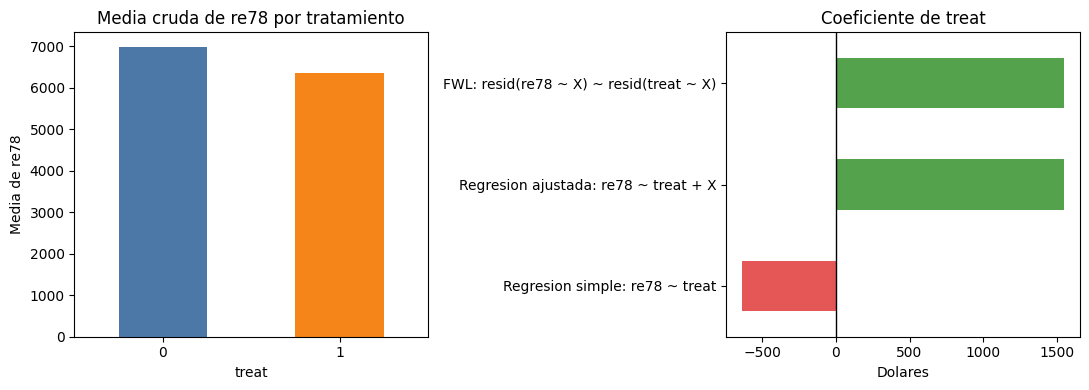

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel 1: diferencia cruda de ingresos 1978.
df.groupby(D)[Y].mean().plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518"])
axes[0].set_title("Media cruda de re78 por tratamiento")
axes[0].set_xlabel("treat")
axes[0].set_ylabel("Media de re78")
axes[0].tick_params(axis="x", rotation=0)

# Panel 2: coeficientes simple, ajustado y FWL.
coef_plot = fwl_lalonde_results.set_index("estimador")["coeficiente_de_treat"]
coef_plot.plot(kind="barh", ax=axes[1], color=["#e45756", "#54a24b", "#54a24b"])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Coeficiente de treat")
axes[1].set_xlabel("Dolares")
axes[1].set_ylabel("")

fig.tight_layout()


### 2.5 Interpretacion

Los resultados muestran una inversion de signo:

- La regresion simple `re78 ~ treat` tiene coeficiente negativo. En la comparacion cruda, los tratados tienen menor ingreso promedio en 1978 que los controles.
- La regresion ajustada `re78 ~ treat + X` tiene coeficiente positivo.
- La regresion FWL con residuales produce el mismo coeficiente que la regresion ajustada.

Esta inversion no contradice FWL. FWL confirma que el coeficiente ajustado puede verse como una regresion entre residuales: la parte de `re78` que no se explica por las covariables y la parte de `treat` que no se explica por las covariables.

La lectura causal requiere el DAG de la pregunta 1. Si las covariables $X$ bloquean caminos backdoor, el coeficiente ajustado se acerca mas a una comparacion causal que la diferencia cruda. Pero FWL por si solo no decide si ajustar es correcto: eso depende de si las variables son confusoras, colliders o mediadoras.

**Respuesta final:** el teorema de Frisch-Waugh-Lovell no prohibe la paradoja de Simpson. En el CSV de LaLonde vemos un ejemplo compatible con Simpson: la asociacion agregada entre `treat` y `re78` es negativa, mientras que la asociacion ajustada por covariables pretratamiento es positiva. FWL no evita ese cambio de signo; lo reproduce y lo explica algebraicamente.

---


## Pregunta 3: ATE mediante Double Machine Learning

En esta pregunta estimamos el ATE mediante Double Machine Learning (DML). La idea es continuar la logica de la pregunta 2: FWL residualiza linealmente `Y` y `D` respecto de covariables `X`; DML conserva esa idea de residualizacion, pero permite usar modelos de machine learning para remover de forma mas flexible la parte de `Y` y `D` explicada por `X`.

El modelo parcialmente lineal es:

$$Y = \theta D + g(X) + \varepsilon,$$

$$D = m(X) + \nu,$$

donde:

- $Y = \text{re78}$.
- $D = \text{treat}$.
- $X = \{\text{age, educ, black, hispan, married, nodegree, re74, re75}\}$.
- $\theta$ es el ATE que queremos estimar.
- $g(X) = E[Y \mid X]$ captura la parte del resultado explicada por covariables.
- $m(X) = E[D \mid X]$ captura la propension al tratamiento dado covariables.


### 3.1 Por que Random Forest y cross-fitting

Usamos DML con **Random Forest + cross-fitting** por razones metodologicas, no por preferencia arbitraria.

Primero, Random Forest permite estimar $g(X)$ y $m(X)$ capturando relaciones no lineales e interacciones entre variables como ingresos previos, edad, educacion, estado civil y pertenencia racial/etnica. Estas relaciones podrian ser demasiado restrictivas para una regresion lineal simple.

Segundo, el **cross-fitting** evita que los modelos auxiliares predigan sobre las mismas observaciones con las que fueron entrenados. El procedimiento es:

1. Dividir los datos en $K$ folds.
2. Para cada fold, entrenar $\hat{g}(X)$ y $\hat{m}(X)$ con los otros folds.
3. Predecir $\hat{Y}$ y $\hat{D}$ en el fold retenido.
4. Construir residuales out-of-fold:

$$\tilde{Y} = Y - \hat{g}(X), \qquad \tilde{D} = D - \hat{m}(X).$$

5. Estimar:

$$\tilde{Y} = \theta \tilde{D} + \eta.$$

Asi, DML extiende FWL: FWL residualiza con modelos lineales; DML residualiza con modelos predictivos flexibles y usa cross-fitting para reducir el sesgo por sobreajuste.

Este procedimiento no elimina los supuestos causales. DML sigue requiriendo ignorabilidad condicional dado $X$ y suficiente positividad. Si hay confusores no observados o mal solapamiento entre NSW y PSID, el estimador puede seguir siendo sensible.


In [38]:
# Double Machine Learning con Random Forest y cross-fitting.
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

X_matrix = df[X_cols].to_numpy()
Y_array = df[Y].to_numpy()
D_array = df[D].to_numpy()

Y_hat = np.zeros(len(df))
D_hat = np.zeros(len(df))
fold_id = np.zeros(len(df), dtype=int)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_matrix), start=1):
    outcome_ml = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )

    treatment_ml = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )

    outcome_ml.fit(X_matrix[train_idx], Y_array[train_idx])
    treatment_ml.fit(X_matrix[train_idx], D_array[train_idx])

    Y_hat[test_idx] = outcome_ml.predict(X_matrix[test_idx])
    D_hat[test_idx] = treatment_ml.predict_proba(X_matrix[test_idx])[:, 1]
    fold_id[test_idx] = fold

Y_res_dml = Y_array - Y_hat
D_res_dml = D_array - D_hat

final_stage = LinearRegression(fit_intercept=False)
final_stage.fit(D_res_dml.reshape(-1, 1), Y_res_dml)

theta_dml = final_stage.coef_[0]

# Error estandar HC0 para la regresion final sin intercepto.
eta_hat = Y_res_dml - theta_dml * D_res_dml
xx = np.sum(D_res_dml ** 2)
var_theta = np.sum((D_res_dml ** 2) * (eta_hat ** 2)) / (xx ** 2)
se_theta = np.sqrt(var_theta)

ci_low = theta_dml - 1.96 * se_theta
ci_high = theta_dml + 1.96 * se_theta

r2_y = r2_score(Y_array, Y_hat)
auc_d = roc_auc_score(D_array, D_hat)

pd.DataFrame({
    "estimador": ["DML Random Forest + cross-fitting"],
    "ATE": [theta_dml],
    "error_estandar": [se_theta],
    "IC_95_inf": [ci_low],
    "IC_95_sup": [ci_high],
    "R2_outcome_oof": [r2_y],
    "AUC_treatment_oof": [auc_d],
}).round(3)


,estimador,ATE,error_estandar,IC_95_inf,IC_95_sup,R2_outcome_oof,AUC_treatment_oof
0,DML Random Forest + cross-fitting,"1,000.5540",792.7880,-553.3110,"2,554.4190",0.1060,0.9090


### 3.2 Diagnostico de las predicciones auxiliares

Revisamos la distribucion de $\hat{m}(X)$, es decir, la probabilidad estimada de tratamiento. Como en la pregunta 1, valores muy cercanos a 0 o 1 indican problemas de positividad practica.


In [39]:
dml_diagnostics = pd.DataFrame({
    "Y": Y_array,
    "D": D_array,
    "Y_hat_oof": Y_hat,
    "D_hat_oof": D_hat,
    "Y_res": Y_res_dml,
    "D_res": D_res_dml,
    "fold": fold_id,
})

print("Resumen de D_hat = P(D=1 | X) out-of-fold:")
display(dml_diagnostics["D_hat_oof"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame())

print("\nDesempeno auxiliar:")
print(f"R2 out-of-fold para outcome: {r2_y:.3f}")
print(f"AUC out-of-fold para tratamiento: {auc_d:.3f}")


Resumen de D_hat = P(D=1 | X) out-of-fold:


,D_hat_oof
count,614.0000
mean,0.3028
std,0.2799
min,0.0030
1%,0.0061
5%,0.0194
25%,0.0564
50%,0.1744
75%,0.5349
95%,0.8156



Desempeno auxiliar:
R2 out-of-fold para outcome: 0.106
AUC out-of-fold para tratamiento: 0.909


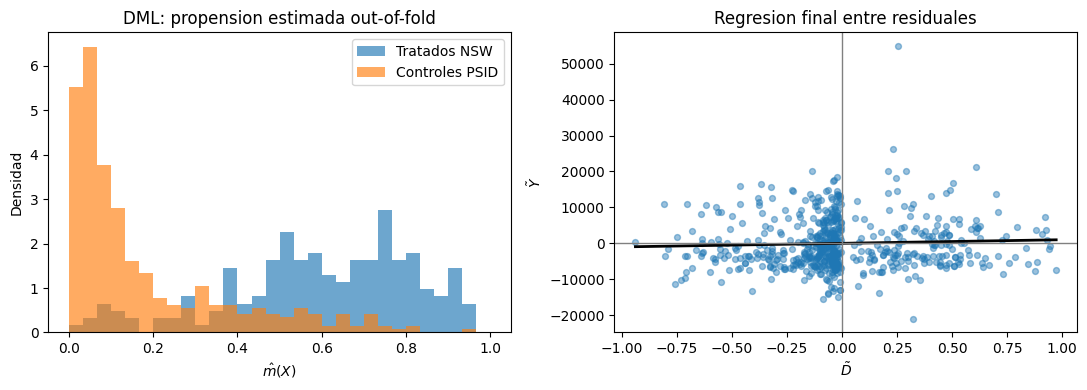

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bins = np.linspace(0, 1, 31)
axes[0].hist(D_hat[D_array == 1], bins=bins, alpha=0.65, density=True, label="Tratados NSW")
axes[0].hist(D_hat[D_array == 0], bins=bins, alpha=0.65, density=True, label="Controles PSID")
axes[0].set_title("DML: propension estimada out-of-fold")
axes[0].set_xlabel(r"$\hat{m}(X)$")
axes[0].set_ylabel("Densidad")
axes[0].legend()

axes[1].scatter(D_res_dml, Y_res_dml, alpha=0.45, s=18)
x_line = np.linspace(D_res_dml.min(), D_res_dml.max(), 100)
axes[1].plot(x_line, theta_dml * x_line, color="black", linewidth=2)
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].axvline(0, color="gray", linewidth=1)
axes[1].set_title("Regresion final entre residuales")
axes[1].set_xlabel(r"$\tilde{D}$")
axes[1].set_ylabel(r"$\tilde{Y}$")

fig.tight_layout()


### 3.3 Comparacion con estimadores anteriores

Comparamos el ATE de DML con los estimadores de las preguntas 1 y 2. La pregunta 2 mostro que la asociacion cruda y la asociacion ajustada responden preguntas distintas. DML sigue la logica ajustada/residualizada de FWL, pero reemplaza la residualizacion lineal por modelos flexibles estimados con cross-fitting.


In [41]:
comparison_results = pd.DataFrame({
    "estimador": [
        "Diferencia cruda",
        "ATE IPW",
        "ATE IPW normalizado",
        "ATE modelo de resultados lineal",
        "ATE modelo de resultados con IPW",
        "FWL / regresion ajustada lineal",
        "DML Random Forest + cross-fitting",
    ],
    "estimacion": [
        ate_naive,
        ate_ipw,
        ate_ipw_normalized,
        ate_outcome,
        ate_outcome_ipw,
        coef_fwl_lalonde,
        theta_dml,
    ],
})

comparison_results.round({"estimacion": 2})


,estimador,estimacion
0,Diferencia cruda,-635.0300
1,ATE IPW,-536.1700
2,ATE IPW normalizado,232.4200
3,ATE modelo de resultados lineal,"1,548.2400"
4,ATE modelo de resultados con IPW,732.6400
5,FWL / regresion ajustada lineal,"1,548.2400"
6,DML Random Forest + cross-fitting,"1,000.5500"


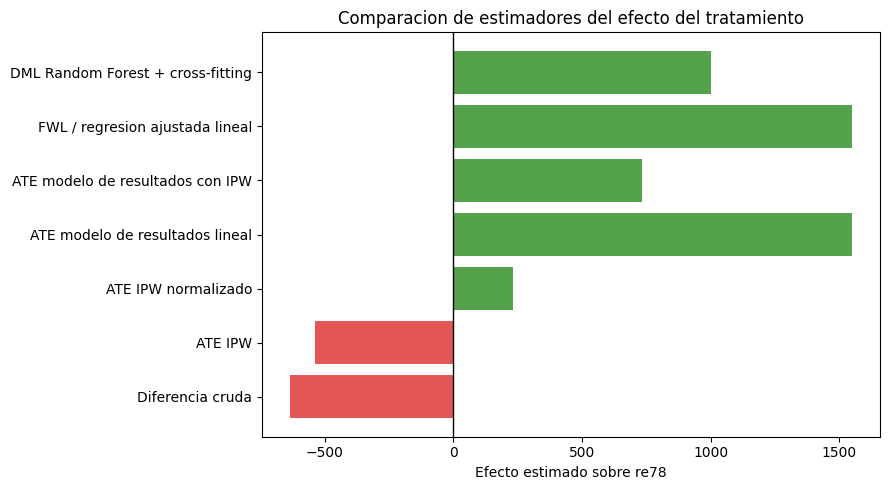

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = comparison_results.copy()
plot_df["color"] = np.where(plot_df["estimacion"] < 0, "#e45756", "#54a24b")

ax.barh(plot_df["estimador"], plot_df["estimacion"], color=plot_df["color"])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Efecto estimado sobre re78")
ax.set_title("Comparacion de estimadores del efecto del tratamiento")
fig.tight_layout()


### 3.4 Interpretacion final

El estimador DML con Random Forest y cross-fitting produce un ATE positivo. Esto es consistente con la lectura de la pregunta 2: la diferencia cruda entre tratados y controles era negativa porque los grupos NSW y PSID no eran comparables antes del tratamiento; al residualizar/ajustar por covariables pretratamiento, la asociacion estimada cambia de direccion.

DML no debe interpretarse como una solucion automatica a todos los problemas causales. Su ventaja es que permite una residualizacion flexible de `re78` y `treat` respecto de `X`, reduciendo restricciones lineales y usando cross-fitting para limitar sobreajuste. Sin embargo, conserva los mismos supuestos causales del analisis anterior:

1. Ignorabilidad condicional dado `X`.
2. Positividad/solapamiento suficiente.
3. Ausencia de confusores no observados relevantes.

En este archivo, la advertencia de positividad sigue siendo importante porque tratados NSW y controles PSID tienen diferencias fuertes de composicion. Por ello, el ATE DML debe leerse como una estimacion ajustada bajo supuestos, no como una prueba definitiva del efecto causal.

**Conclusion:** DML extiende la intuicion de FWL. FWL muestra como obtener el coeficiente ajustado mediante residualizacion lineal; DML estima el efecto usando residuales obtenidos con modelos de machine learning y cross-fitting. En LaLonde, esta estrategia vuelve a mostrar que la comparacion cruda es enganosa y que el efecto ajustado del tratamiento es positivo bajo los supuestos del modelo causal.
